
#  Experimento: Muestras

### Tiempo de entrenamiento de SoM (somJ) vs MiniSom en función del nº de muestras con 5-fold CV

In [1]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.manifold import TSNE
import umap
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import KFold
import pandas as pd

from somJ.som import SoM
from minisom import MiniSom
import somJ.config as config
from functions import load_dataset

/home/jaume/miniconda3/envs/tfg_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-05-28 19:49:13.664825: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-05-28 19:49:13.665380: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-05-28 19:49:13.667809: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-05-28 19:49:13.673741: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to r

KeyboardInterrupt: 

In [ ]:
from sklearn.exceptions import DataConversionWarning
import warnings
warnings.filterwarnings("ignore", category=DataConversionWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)


In [ ]:

sample_sizes = [1000, 5000, 10000, 20000, 40000]
n_splits     = 5

# Carga y normalización
X_all, y_all = load_dataset("MNIST")
scaler   = MinMaxScaler()
X_all    = scaler.fit_transform(X_all)

# Para guardar resultados de cada fold
times_som  = {s: [] for s in sample_sizes}
times_pca  = {s: [] for s in sample_sizes}
times_lda  = {s: [] for s in sample_sizes}
times_tsne = {s: [] for s in sample_sizes}
times_umap = {s: [] for s in sample_sizes}

kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

for n in sample_sizes:
    print(f"\n=== Muestras: {n} ===")
    X_sample = X_all[:(n*5)]
    y_sample = y_all[:(n*5)]
    # 5-fold splits
    for fold, (train_idx, _) in enumerate(kf.split(X_sample), 1):
        X_train = X_sample[train_idx]
        y_train = y_sample[train_idx]
        print(f" Fold {fold}/{n_splits}", end='… ')
        
        # --- SoM (somJ) ---
        som = SoM(
            method=config.INIT_METHOD,
            data=X_train,
            total_nodes=config.TOTAL_NODES
        )
        t0 = time.time()
        som.train(
            train_data=X_train,
            learn_rate=config.LEARNING_RATE,
            epochs=1,
            sigma=config.SIGMA,
            prog_bar=False
        )
        times_som[n].append(time.time() - t0)
        
        # ---- PCA ----
        t0 = time.time()
        pca = PCA(n_components=2, random_state=42)
        _ = pca.fit_transform(X_train)
        times_pca[n].append(time.time() - t0)
        
        # ---- LDA ----
        t0 = time.time()
        lda = LinearDiscriminantAnalysis(n_components=2)
        _ = lda.fit_transform(X_train, y_train)
        times_lda[n].append(time.time() - t0)
        
        # ---- t-SNE ----
        t0 = time.time()
        tsne = TSNE(n_components=2, init='random', random_state=42, verbose=0)
        _ = tsne.fit_transform(X_train)
        times_tsne[n].append(time.time() - t0)
        
        # ---- UMAP ----
        t0 = time.time()
        umap_model = umap.UMAP(n_components=2, random_state=42)
        _ = umap_model.fit_transform(X_train)
        times_umap[n].append(time.time() - t0)
        
        
        print("OK")


=== Muestras: 1000 ===
 Fold 1/5… OK
 Fold 2/5… OK
 Fold 3/5… OK
 Fold 4/5… OK
 Fold 5/5… OK

=== Muestras: 5000 ===
 Fold 1/5… OK
 Fold 2/5… OK
 Fold 3/5… OK
 Fold 4/5… OK
 Fold 5/5… OK

=== Muestras: 10000 ===
 Fold 1/5… OK
 Fold 2/5… OK
 Fold 3/5… OK
 Fold 4/5… OK
 Fold 5/5… OK

=== Muestras: 20000 ===
 Fold 1/5… OK
 Fold 2/5… OK
 Fold 3/5… OK
 Fold 4/5… OK
 Fold 5/5… OK

=== Muestras: 40000 ===
 Fold 1/5… OK
 Fold 2/5… OK
 Fold 3/5… OK
 Fold 4/5… OK
 Fold 5/5… OK


In [ ]:
results = []
for sample in sample_sizes:
    row = {"size": sample}
    for name, times_dict in [("SOM", times_som),
                                ("PCA", times_pca),
                             ("LDA", times_lda),
                             ("t-SNE", times_tsne),
                             ("UMAP", times_umap)]:
        arr = np.array(times_dict[sample], dtype=float)
        row[f"{name}_mean"] = np.nanmean(arr)
        row[f"{name}_std"]  = np.nanstd(arr, ddof=1)
    results.append(row)

In [ ]:
df_results = pd.DataFrame(results)
print("\nResumen de tiempos (media ± std) por técnica y dimensión:")
print(df_results.to_string(index=False))


Resumen de tiempos (media ± std) por técnica y dimensión:
 size  SOM_mean  SOM_std  PCA_mean  PCA_std  LDA_mean  LDA_std  t-SNE_mean  t-SNE_std  UMAP_mean  UMAP_std
 1000  0.775456 0.067078  0.053708 0.006064  0.596857 0.387089    7.760978   1.656349   8.817738  0.258541
 5000  3.943574 0.106712  0.101824 0.005691  0.871829 0.260239   39.912317   2.885046   8.165037  0.627278
10000  7.427202 0.369994  0.158140 0.014378  1.345205 0.074871   87.607752   2.396649  16.422203  0.232072
20000  8.585530 0.675151  0.171581 0.027317  1.698697 0.210180  102.635206   1.009699  20.523569  0.707267
40000  8.951779 0.693262  0.204242 0.056725  1.905093 0.426997  104.359644   2.546793  20.977913  0.938000


In [ ]:
df_results

,size,SOM_mean,SOM_std,PCA_mean,PCA_std,LDA_mean,LDA_std,t-SNE_mean,t-SNE_std,UMAP_mean,UMAP_std
0,1000,0.775456,0.067078,0.053708,0.006064,0.596857,0.387089,7.760978,1.656349,8.817738,0.258541
1,5000,3.943574,0.106712,0.101824,0.005691,0.871829,0.260239,39.912317,2.885046,8.165037,0.627278
2,10000,7.427202,0.369994,0.158140,0.014378,1.345205,0.074871,87.607752,2.396649,16.422203,0.232072
3,20000,8.585530,0.675151,0.171581,0.027317,1.698697,0.210180,102.635206,1.009699,20.523569,0.707267
4,40000,8.951779,0.693262,0.204242,0.056725,1.905093,0.426997,104.359644,2.546793,20.977913,0.938000


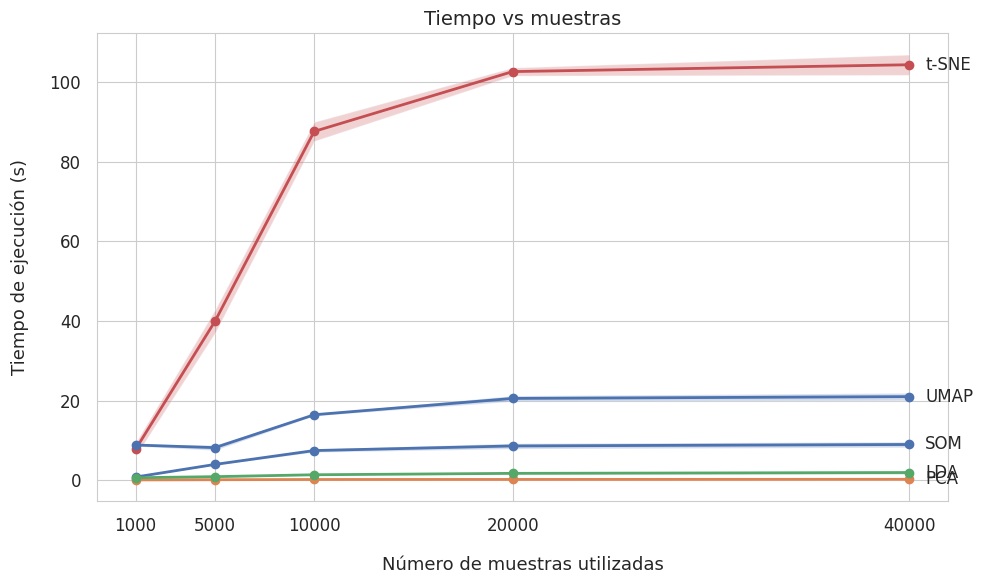

In [3]:

# --- Configuración de estilo ---
sns.set_style('whitegrid')
sns.set_palette('deep', n_colors=4)
plt.rc('font', size=12)
plt.rc('axes', titlesize=14, labelsize=13)

# --- Extraer datos de df_results ---
sample    = df_results['size'].values
mean_som  = df_results['SOM_mean'].values
std_som   = df_results['SOM_std'].values
mean_pca  = df_results['PCA_mean'].values
std_pca   = df_results['PCA_std'].values
mean_lda  = df_results['LDA_mean'].values
std_lda   = df_results['LDA_std'].values
mean_tsne = df_results['t-SNE_mean'].values
std_tsne  = df_results['t-SNE_std'].values
mean_umap = df_results['UMAP_mean'].values
std_umap  = df_results['UMAP_std'].values

# --- Gráfica ---
fig, ax = plt.subplots(figsize=(10, 6))
fig.subplots_adjust(left=0.12, right=0.95, top=0.90, bottom=0.12)

methods = [
    ('SOM',   mean_som,   std_som),
    ('PCA',   mean_pca,   std_pca),
    ('LDA',   mean_lda,   std_lda),
    ('t-SNE', mean_tsne,  std_tsne),
    ('UMAP',  mean_umap,  std_umap),
]

for label, mean_vals, std_vals in methods:
    mean_arr = np.array(mean_vals, dtype=float)
    std_arr  = np.array(std_vals,  dtype=float)
    valid    = ~np.isnan(mean_arr)

    ax.plot(
        sample[valid],
        mean_arr[valid],
        marker='o',
        linewidth=2,
        label=label
    )
    ax.fill_between(
        sample[valid],
        mean_arr[valid] - std_arr[valid],
        mean_arr[valid] + std_arr[valid],
        alpha=0.25
    )

# Etiquetas directas al final de cada curva
for label, mean_vals, _ in methods:
    mean_arr = np.array(mean_vals, dtype=float)
    valid_ix = np.where(~np.isnan(mean_arr))[0]
    if len(valid_ix) > 0:
        last_ix = valid_ix[-1]
        x, y = sample[last_ix], mean_arr[last_ix]
        ax.text(x * 1.02, y, label, va='center')

# Escalas y etiquetas
ax.set_xscale('linear')
ax.set_xticks(sample)
ax.tick_params(axis='x', pad=8)
ax.tick_params(axis='y', pad=8)
ax.xaxis.labelpad = 15
ax.yaxis.labelpad = 15

ax.set_xlabel('Número de muestras utilizadas')
ax.set_ylabel('Tiempo de ejecución (s)')
ax.set_title('Tiempo vs muestras')

plt.tight_layout()
plt.savefig("g_time_comp/tiempo_vs_muestras_5fold.png",dpi=300)
plt.show()